In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [42]:
import matplotlib.pyplot as plt

In [24]:
marathon = pd.read_csv("../data/marathon-data.csv")
marathon.head()

,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


In [4]:
marathon


,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59
...,...,...,...,...
37245,18,M,04:24:24,09:32:57
37246,36,M,04:35:43,09:33:28
37247,51,M,04:22:35,09:33:40
37248,55,W,04:58:06,10:00:40


In [5]:
marathon["gender"].unique()

array(['M', 'W'], dtype=object)

In [6]:
marathon.dtypes

age        int64
gender    object
split     object
final     object
dtype: object

In [30]:
def convert_time(s):
    # h, m, s = map(int, s.split(':'))
    return pd.to_timedelta(s)

In [31]:
marathon = pd.read_csv("../data/marathon-data.csv", converters={"split": convert_time,
                                                                "final": convert_time})
marathon.head()

,age,gender,split,final
0,33,M,0 days 01:05:38,0 days 02:08:51
1,32,M,0 days 01:06:26,0 days 02:09:28
2,31,M,0 days 01:06:49,0 days 02:10:42
3,38,M,0 days 01:06:16,0 days 02:13:45
4,31,M,0 days 01:06:32,0 days 02:13:59


In [33]:
marathon["split"]

0       0 days 01:05:38
1       0 days 01:06:26
2       0 days 01:06:49
3       0 days 01:06:16
4       0 days 01:06:32
              ...      
37245   0 days 04:24:24
37246   0 days 04:35:43
37247   0 days 04:22:35
37248   0 days 04:58:06
37249   0 days 04:59:49
Name: split, Length: 37250, dtype: timedelta64[ns]

In [35]:
marathon["split_sec"] = marathon["split"].astype(int) / 1E9

In [36]:
marathon["final_sec"] = marathon["final"].astype(int) / 1E9
marathon.head()

,age,gender,split,final,split_sec,final_sec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0


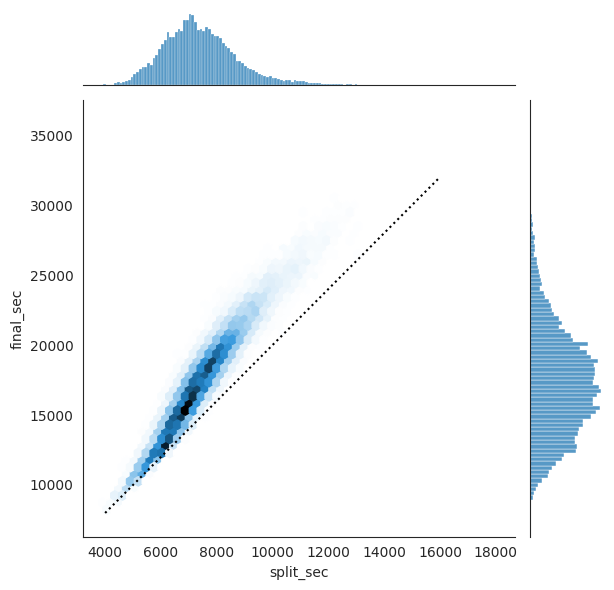

In [37]:
with sns.axes_style("white"):
    g = sns.jointplot(x="split_sec", y="final_sec", data=marathon, kind="hex")
    g.ax_joint.plot(np.linspace(4000, 16000),
                    np.linspace(8000, 32000), ":k")

In [38]:
# the split fraction will measure the degree to which each runner negative-splits or positive-splits the race.
# negative split: faster in the second half.
# positive split: slower in the second half (the usual).

marathon["split_frac"] = 1 - 2 * marathon["split_sec"] / marathon["final_sec"]
marathon.head()

,age,gender,split,final,split_sec,final_sec,split_frac
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842


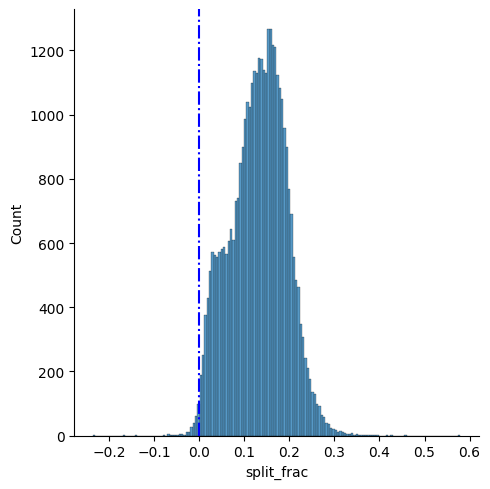

In [46]:
# Make a distribution plot of the split fraction

sns.displot(marathon["split_frac"], kde=False)
plt.axvline(0, color="blue", linestyle="-.");

In [47]:
sum(marathon["split_frac"] < 0)

251

So we see that 251 people negative split the marathon!

### Pair grid 
To check correlation between split fraction and other variables

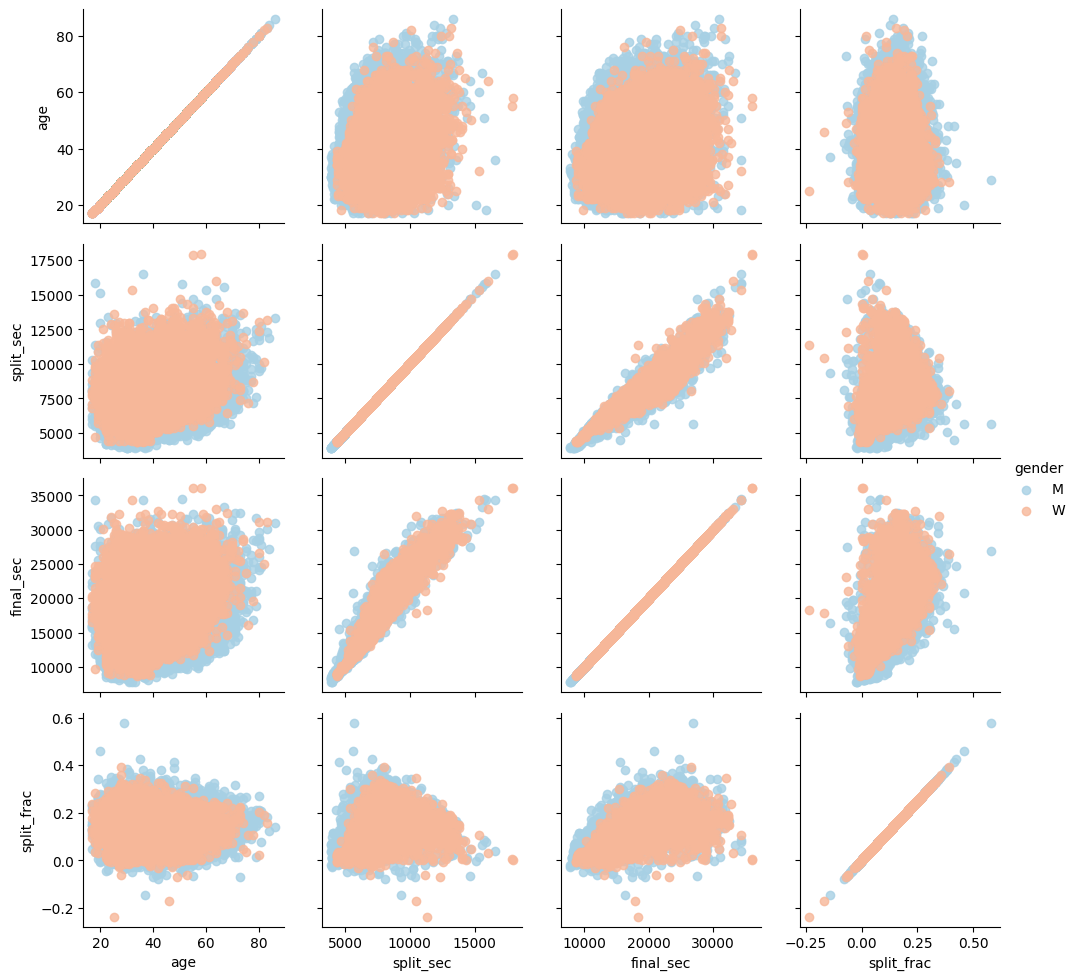

In [48]:
g = sns.PairGrid(marathon, vars=["age", "split_sec", "final_sec", "split_frac"],
                 hue="gender", palette="RdBu_r")
g.map(plt.scatter, alpha=0.8)
g.add_legend();

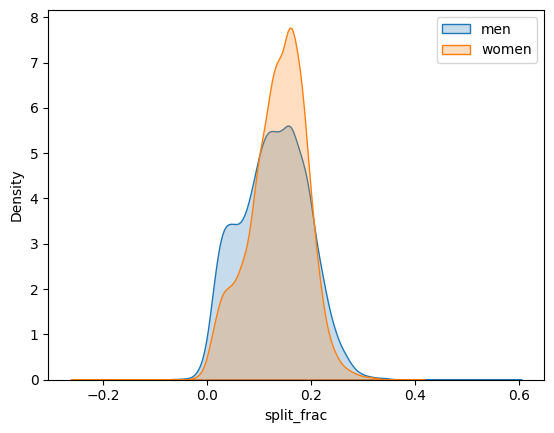

In [58]:
# Splitting by men and women

sns.kdeplot(marathon["split_frac"][marathon["gender"]== "M"], label="men", fill=True)
sns.kdeplot(marathon["split_frac"][marathon["gender"]== "W"], label="women", fill=True)
plt.legend()
plt.xlabel("split_frac");

<Axes: xlabel='gender', ylabel='split_frac'>

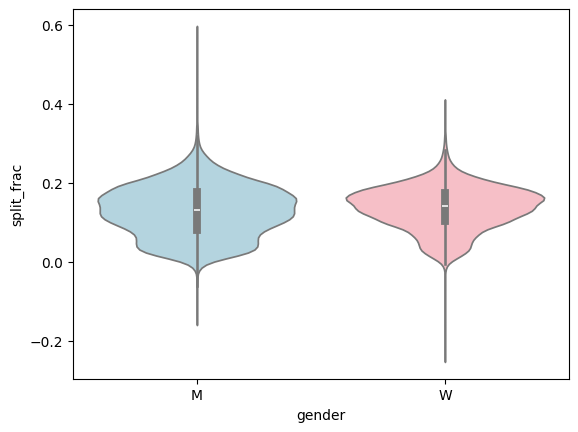

In [64]:
# To compare distributions, we'll use a violin plot
sns.violinplot(marathon, x= "gender", y ="split_frac", hue="gender", palette=["lightblue", "lightpink"]);

In [65]:
marathon["age_decade"] = marathon["age"].map(lambda age: 10 * (age // 10))

In [66]:
marathon

,age,gender,split,final,split_sec,final_sec,split_frac,age_decade
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756,30
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262,30
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443,30
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097,30
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842,30
...,...,...,...,...,...,...,...,...
37245,18,M,0 days 04:24:24,0 days 09:32:57,15864.0,34377.0,0.077057,10
37246,36,M,0 days 04:35:43,0 days 09:33:28,16543.0,34408.0,0.038421,30
37247,51,M,0 days 04:22:35,0 days 09:33:40,15755.0,34420.0,0.084544,50
37248,55,W,0 days 04:58:06,0 days 10:00:40,17886.0,36040.0,0.007436,50


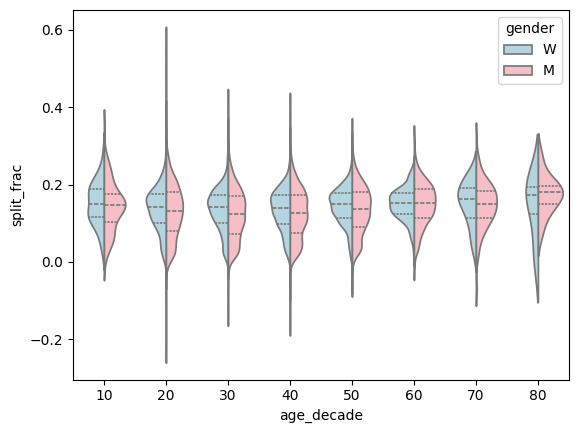

In [70]:
with sns.axes_style(style=None):
    sns.violinplot(x="age_decade", y="split_frac", hue="gender", data=marathon,
                   split=True, inner="quartile",
                   palette=["lightblue", "lightpink"]);

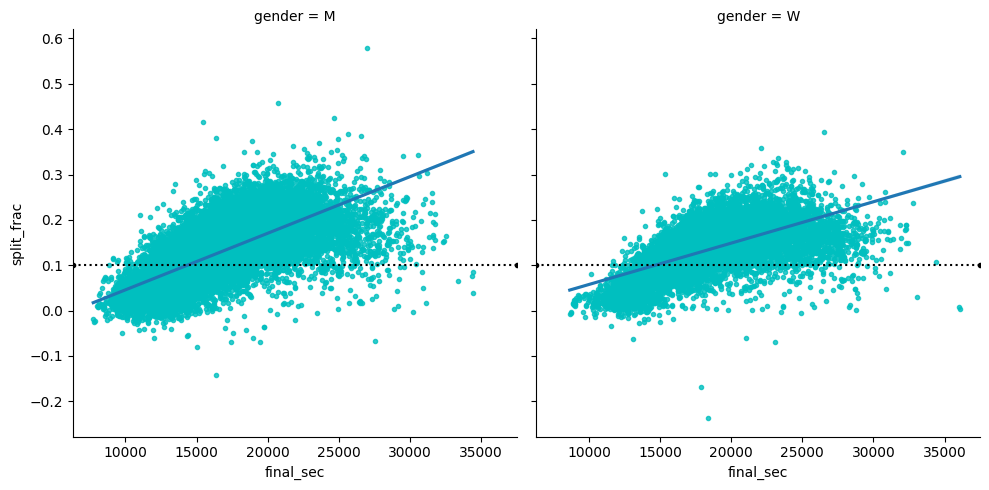

In [71]:
# A regplot to see more clearly the men runners with the negative split

g = sns.lmplot(x='final_sec', y='split_frac', col='gender', data=marathon,
               markers=".", scatter_kws=dict(color='c'))
g.map(plt.axhline, y=0.1, color="k", ls=":");

Fast splits and negative splits too are more of the competitive or elite runners.